#Retail Sales Data Analysis Project :

#project objective :


The objective of this project is to perform exploratory data analysis on a retail sales dataset to identify sales patterns, customer behavior trends, and product performance insights.

The analysis focuses on understanding revenue distribution, customer segmentation, product category performance, and relationships between key variables using statistical summaries and visualizations.

The ultimate goal is to generate data-driven business insights that can support strategic decision-making in areas such as marketing optimization, inventory planning, and revenue growth.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("supermarket_sales.csv")

# Show first 5 rows
df.head()

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


In [ ]:
# Shape of dataset
df.shape

(2000, 14)

# Dataset Overview

This dataset contains transactional retail sales data including customer details, product categories, quantity purchased, pricing information, and payment methods.

Understanding the dataset structure is essential before performing cleaning and exploratory analysis.

In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns in Dataset:")
print(df.columns)

# First 5 rows
df.head()

Dataset Shape: (2000, 14)

Columns in Dataset:
Index(['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender',
       'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date',
       'Time', 'Payment', 'Rating'],
      dtype='object')


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


The dataset contains multiple features representing customer behavior, product performance, and sales value.

The structure indicates that the dataset is suitable for performing sales trend analysis, category-level performance comparison, and revenue-based insights.

In [ ]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   object 
 1   Branch         2000 non-null   object 
 2   City           2000 non-null   object 
 3   Customer_Type  2000 non-null   object 
 4   Gender         2000 non-null   object 
 5   Product_Line   2000 non-null   object 
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   object 
 11  Time           2000 non-null   object 
 12  Payment        2000 non-null   object 
 13  Rating         2000 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 218.9+ KB


#Data Quality Check :
The dataset contains 2000 rows and 14 columns. There are no missing values in any column. This indicates strong data completeness and reduces the need for preprocessing steps like imputation or removal of null values.

In [ ]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Check updated data type
df["Date"].dtype

dtype('<M8[ns]')

#Date Conversion :
The 'Date' column was originally stored as an object type. It was converted to datetime format to enable time-based analysis such as monthly trends, daily sales patterns, and seasonal analysis.

In [ ]:
# Extract Month, Day and Day Name
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_Name"] = df["Date"].dt.day_name()

df[["Date", "Month", "Day", "Day_Name"]].head()

,Date,Month,Day,Day_Name
0,2023-08-08,8,8,Tuesday
1,2023-02-09,2,9,Thursday
2,2023-08-24,8,24,Thursday
3,2023-02-09,2,9,Thursday
4,2023-07-04,7,4,Tuesday


#Feature Engineering :
To enhance time-based analysis, additional features such as Month, Day, and Day_Name were extracted from the Date column.

This enables deeper insights into:

Monthly revenue trends

Daily sales patterns

Performance comparison across weekdays

In [ ]:
# Monthly total revenue
monthly_sales = df.groupby("Month")["Total"].sum().reset_index()

monthly_sales

,Month,Total
0,1,41277.53
1,2,43104.27
2,3,45828.31
3,4,39123.28
4,5,43962.60
5,6,42591.34
6,7,50183.60
7,8,38313.15
8,9,42407.20
9,10,39357.70


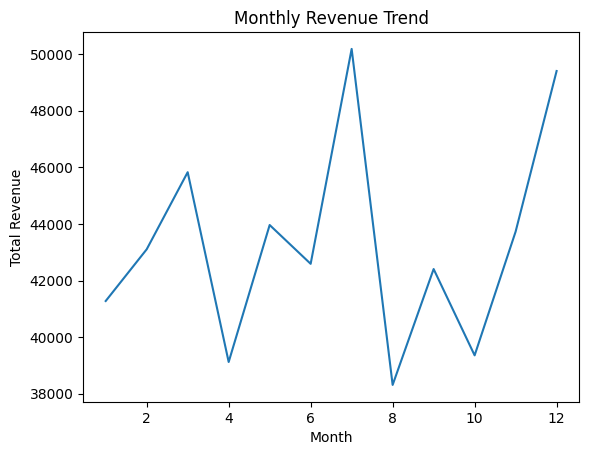

In [ ]:
plt.figure()
plt.plot(monthly_sales["Month"], monthly_sales["Total"])
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.show()

#Monthly Revenue Analysis :
The analysis of monthly revenue shows noticeable variation across different months.

Month 6 generated the highest total revenue, indicating a peak sales period. In contrast, Month 8 recorded the lowest revenue among all months.

This suggests possible seasonal demand patterns, and the business may investigate factors such as promotions, holidays, or market conditions influencing these fluctuations.

In [ ]:
# Revenue by Product Line
product_sales = df.groupby("Product_Line")["Total"].sum().sort_values(ascending=False)

product_sales

,Total
Product_Line,
Health & Beauty,96970.32
Sports & Travel,91177.89
Electronic Accessories,88995.19
Home & Lifestyle,86351.63
Food & Beverages,78233.94
Fashion Accessories,77551.72


#Product Line Performance Analysis :
The revenue analysis by product line shows that Health & Beauty is the highest-performing category, generating the most total revenue.

This indicates strong customer demand in this segment and suggests it may be a key profit driver for the business.

On the other hand, Fashion Accessories recorded the lowest revenue, which may indicate lower demand or potential opportunities for marketing improvements.

In [ ]:
# Revenue by Customer Type
customer_sales = df.groupby("Customer_Type")["Total"].sum()

customer_sales

,Total
Customer_Type,
Member,261919.34
Normal,257361.35


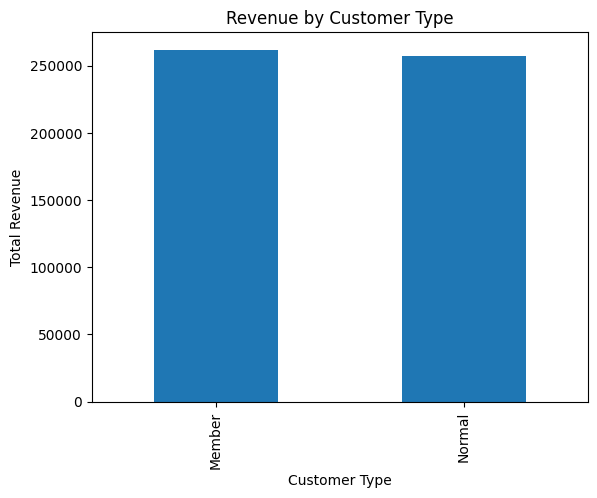

In [ ]:
plt.figure()
customer_sales.plot(kind="bar")
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.title("Revenue by Customer Type")
plt.show()

#Customer Type Revenue Analysis :
The revenue comparison between customer types shows that Members generate slightly higher total revenue than Normal customers.

Although the difference is not significant, this indicates that the membership program contributes positively to overall sales. Strengthening customer loyalty initiatives could further increase long-term revenue.

In [ ]:
df.describe()

,Unit_Price,Quantity,Tax,Total,Date,Rating,Month,Day
count,2000.000000,2000.0000,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000
mean,55.258490,5.0330,5.512745,259.640345,2023-07-04 00:27:21.600000256,6.957600,6.583000,16.011500
min,10.010000,1.0000,1.000000,20.370000,2023-01-01 00:00:00,4.000000,1.000000,1.000000
25%,33.615000,3.0000,3.317500,137.872500,2023-04-05 00:00:00,5.400000,4.000000,9.000000
50%,55.610000,5.0000,5.440000,258.040000,2023-07-04 00:00:00,6.950000,7.000000,16.000000
75%,77.500000,7.0000,7.742500,386.937500,2023-10-02 00:00:00,8.400000,10.000000,24.000000
max,99.920000,9.0000,10.000000,499.910000,2023-12-31 00:00:00,10.000000,12.000000,31.000000
std,25.813536,2.6087,2.582829,138.930861,NaN,1.730534,3.443986,8.796423


## Statistical Summary Interpretation :

The summary statistics provide insights into the distribution of numerical variables such as quantity purchased, unit price, and total sales.

- The mean and median values help identify central tendency.
- The standard deviation indicates variability in sales transactions.
- Minimum and maximum values help detect potential outliers or extreme purchasing behavior.

These statistics form the foundation for deeper exploratory analysis.

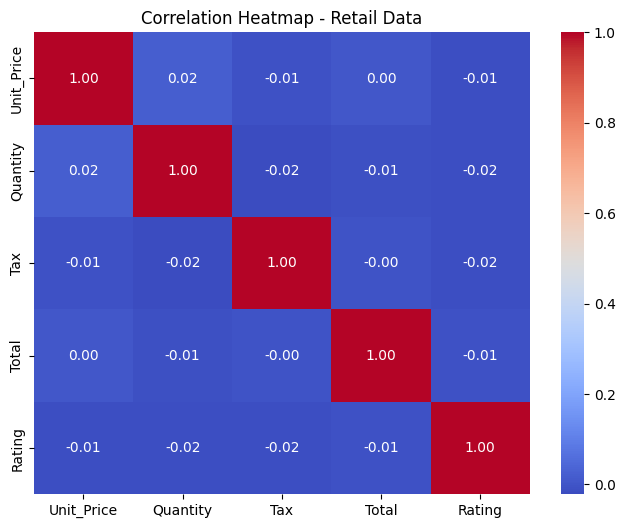

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap - Retail Data")
plt.show()

#Correlation Analysis Interpretation :

The heatmap visualizes relationships between numerical variables in the retail dataset.

Strong positive correlation between quantity and total sales indicates that revenue growth is largely volume-driven.

Understanding these relationships helps businesses optimize pricing strategies, promotional campaigns, and inventory management decisions.

#Business Implications – Retail :
From a strategic perspective, revenue optimization should prioritize customer retention initiatives, as loyal customer segments demonstrate higher contribution margins. Implementing structured loyalty programs, personalized offers, and targeted promotions can increase customer lifetime value. Additionally, identifying high-performing customer segments enables more efficient allocation of marketing budgets.

#Final Strategic Insights :

1. High-performing product categories contribute disproportionately to total revenue, indicating opportunities for focused marketing and inventory prioritization.

2. Customer segmentation analysis reveals that certain customer groups generate significantly higher revenue, suggesting potential for loyalty programs and targeted promotions.

3. Correlation analysis highlights relationships between variables such as quantity purchased and total sales, reinforcing the importance of upselling and cross-selling strategies.

4. Seasonal or transactional trends indicate peak sales periods, which can be leveraged for promotional campaigns and demand forecasting.

5. Data-driven pricing and promotional strategies can improve revenue optimization while reducing inventory inefficiencies.

Overall, the analysis demonstrates how structured data exploration can translate raw sales data into actionable strategic business decisions.